<a href="https://colab.research.google.com/github/AnnEldho/Data-Science-Lab/blob/main/Lab_Exercise_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(df.head())

Saving Titanic_Train.csv to Titanic_Train.csv
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0 

# Histogram

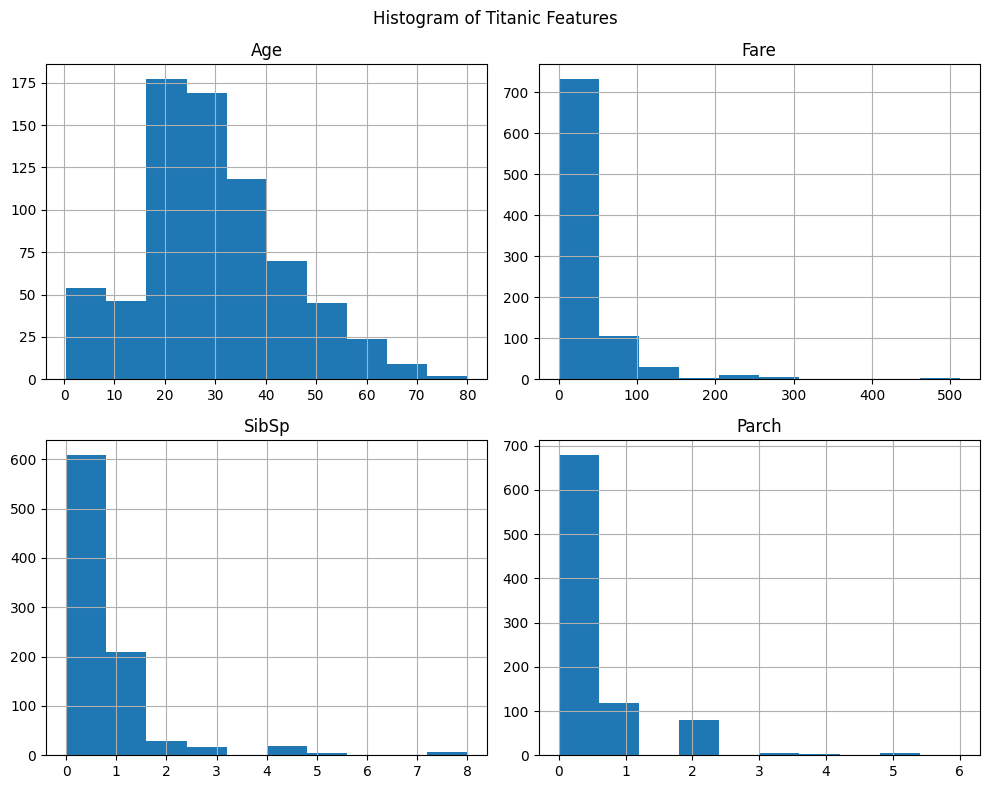

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Titanic_Train.csv")

df[["Age", "Fare", "SibSp", "Parch"]].hist(
    figsize=(10, 8),
    bins=10
)

plt.suptitle("Histogram of Titanic Features")
plt.tight_layout()
plt.show()

# Quartile Plot

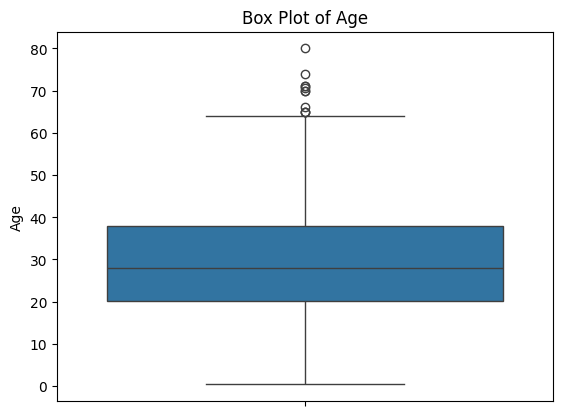

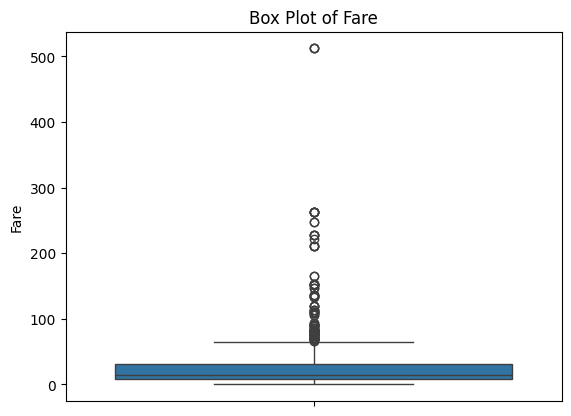

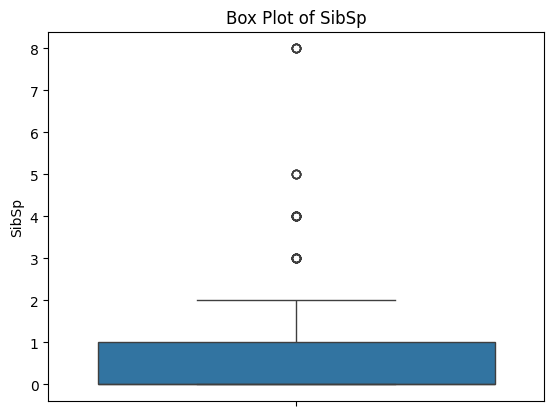

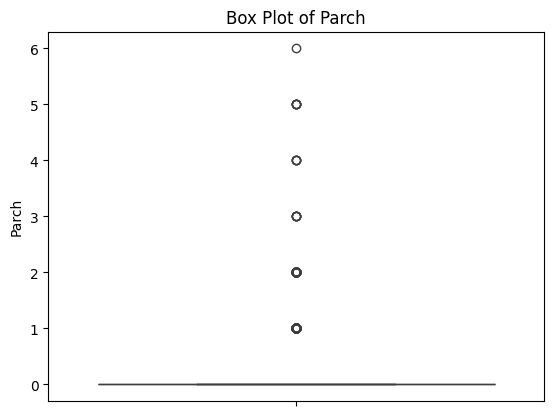

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["Age", "Fare", "SibSp", "Parch"]

for feature in features:
    sns.boxplot(y=df[feature])
    plt.title("Box Plot of " + feature)
    plt.ylabel(feature)
    plt.show()

# Distribution Chart

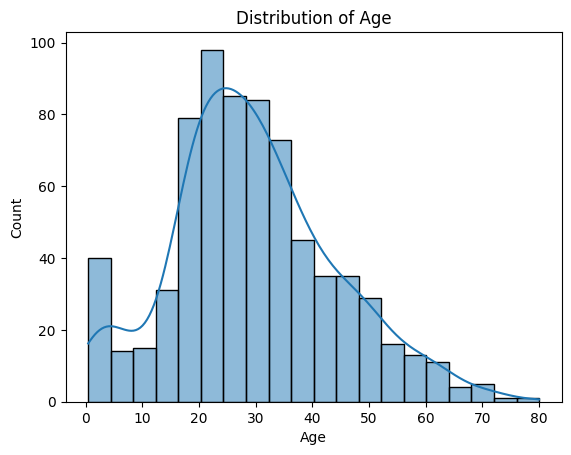

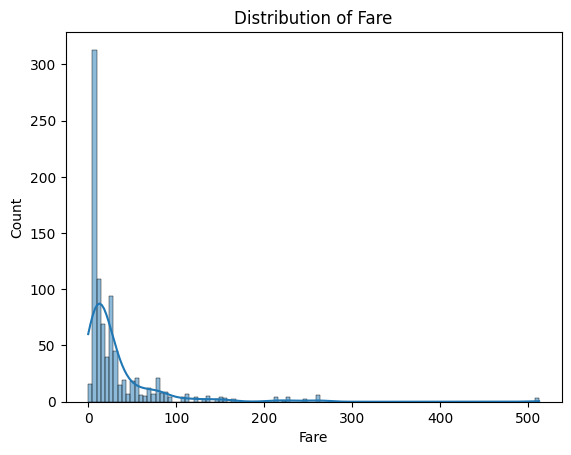

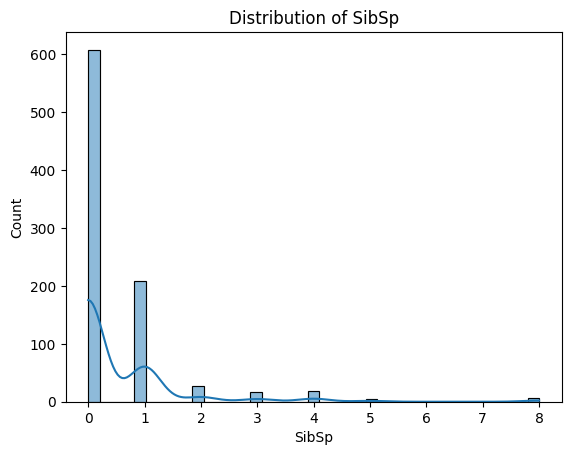

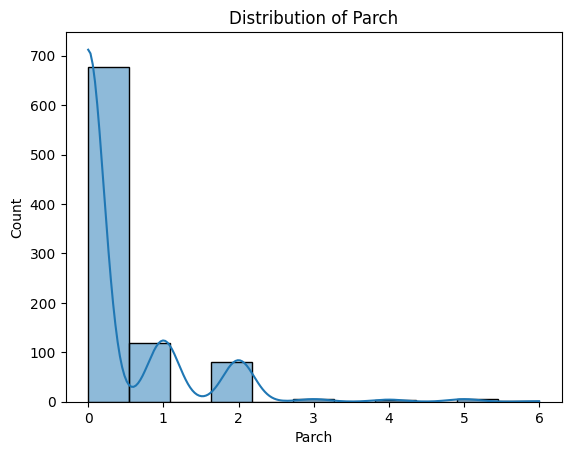

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["Age", "Fare", "SibSp", "Parch"]

for feature in features:
    sns.histplot(df[feature], kde=True)
    plt.title("Distribution of " + feature)
    plt.xlabel(feature)
    plt.ylabel("Count")
    plt.show()

# Scatterplot

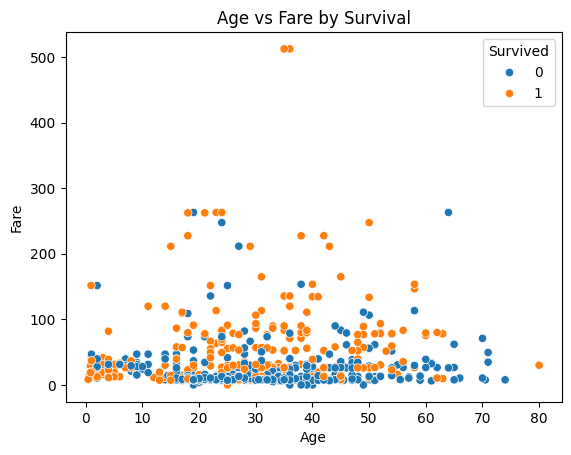

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    hue="Survived"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

# Scatter Multiple

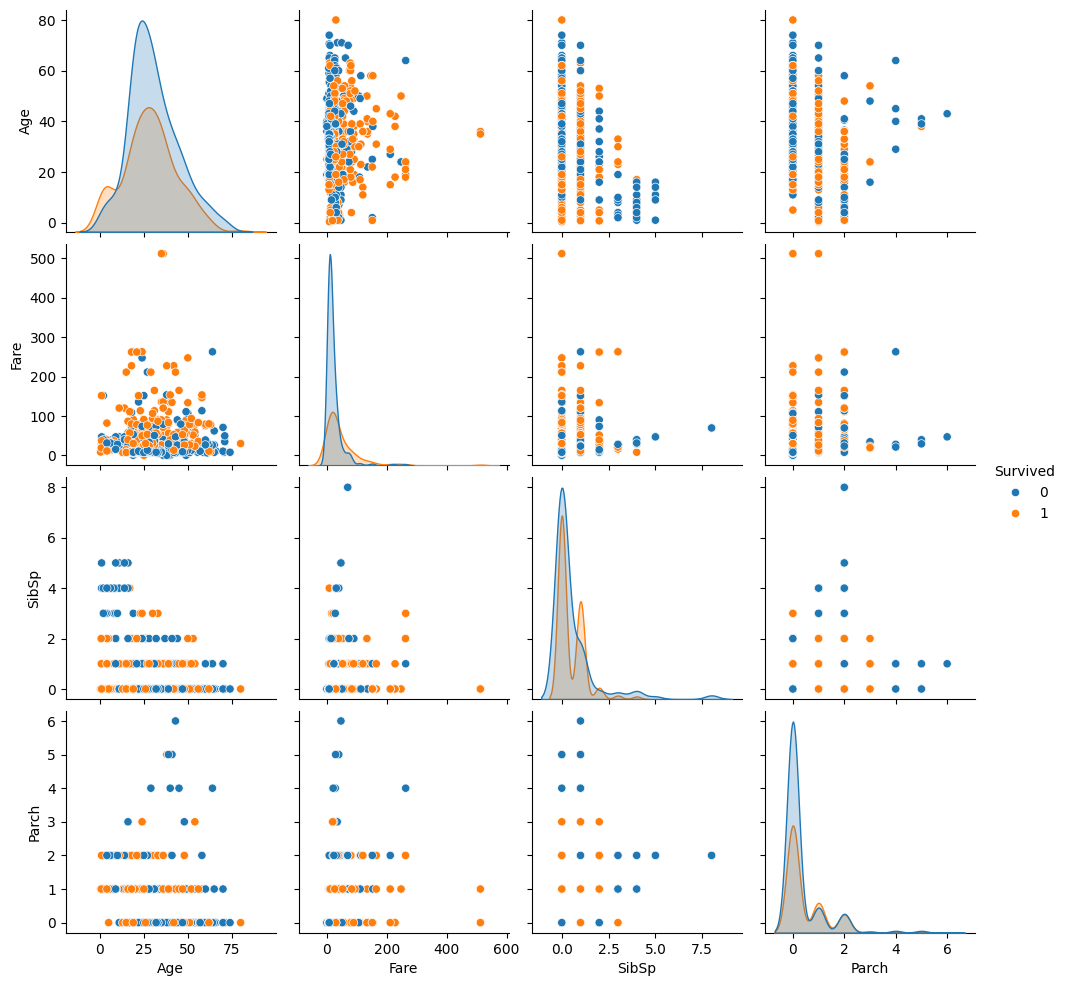

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["Age", "Fare", "SibSp", "Parch"]

sns.pairplot(
    df[features + ["Survived"]],
    hue="Survived"
)

plt.show()

# Scatter Matrix

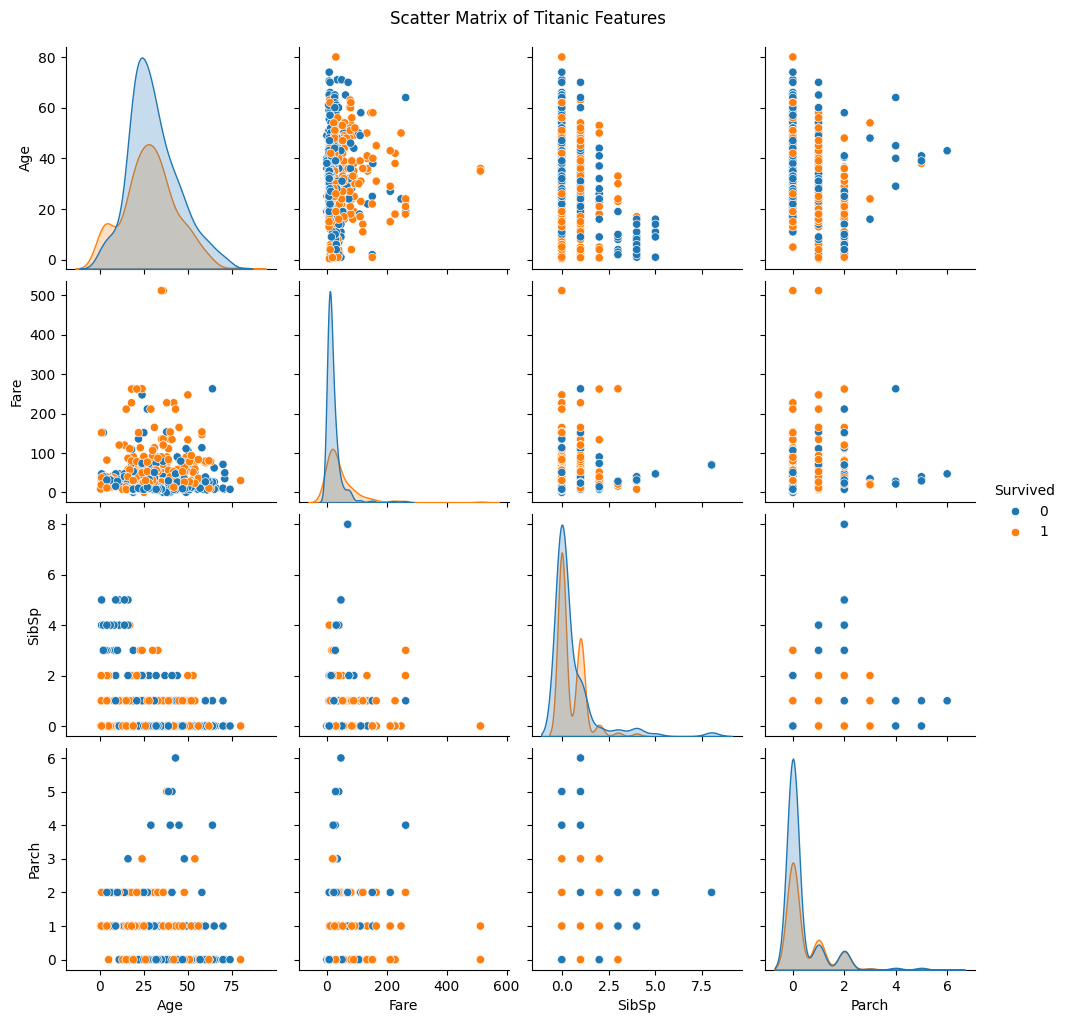

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["Age", "Fare", "SibSp", "Parch"]

sns.pairplot(df[features + ["Survived"]], hue="Survived")

plt.suptitle("Scatter Matrix of Titanic Features", y=1.02)
plt.show()

# Bubble Chart

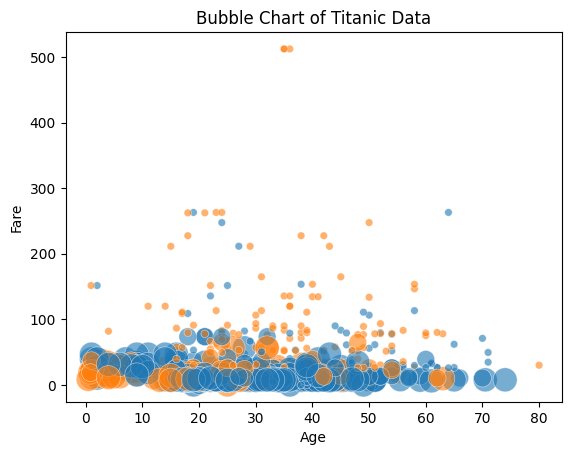

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="Age",
    y="Fare",
    size="Pclass",
    hue="Survived",
    sizes=(30, 300),
    alpha=0.6,
    legend=False
)

plt.title("Bubble Chart of Titanic Data")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


# Density Chart

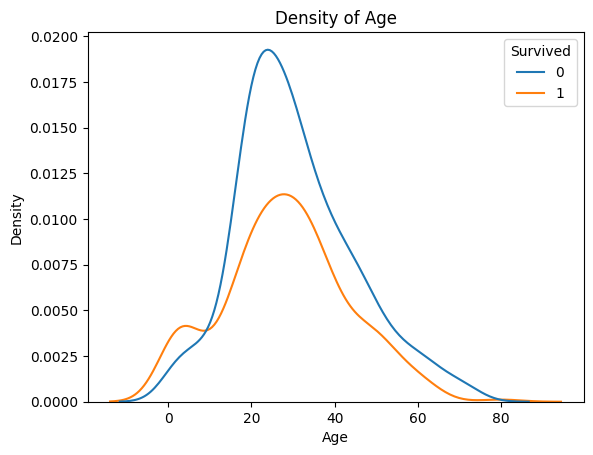

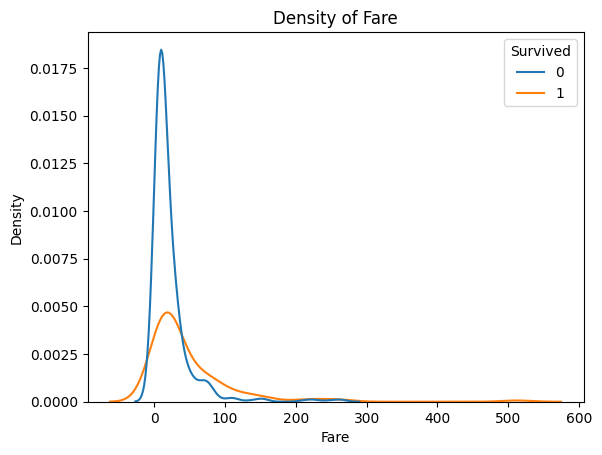

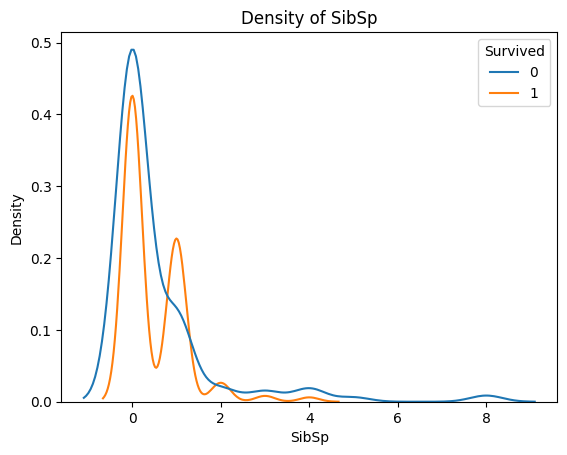

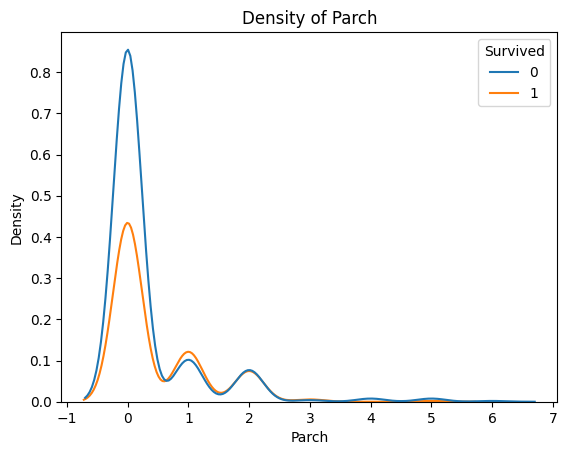

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ["Age", "Fare", "SibSp", "Parch"]

for feature in features:
    sns.kdeplot(
        data=df,
        x=feature,
        hue="Survived"
    )

    plt.title("Density of " + feature)
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.show()

# Parallel Chart

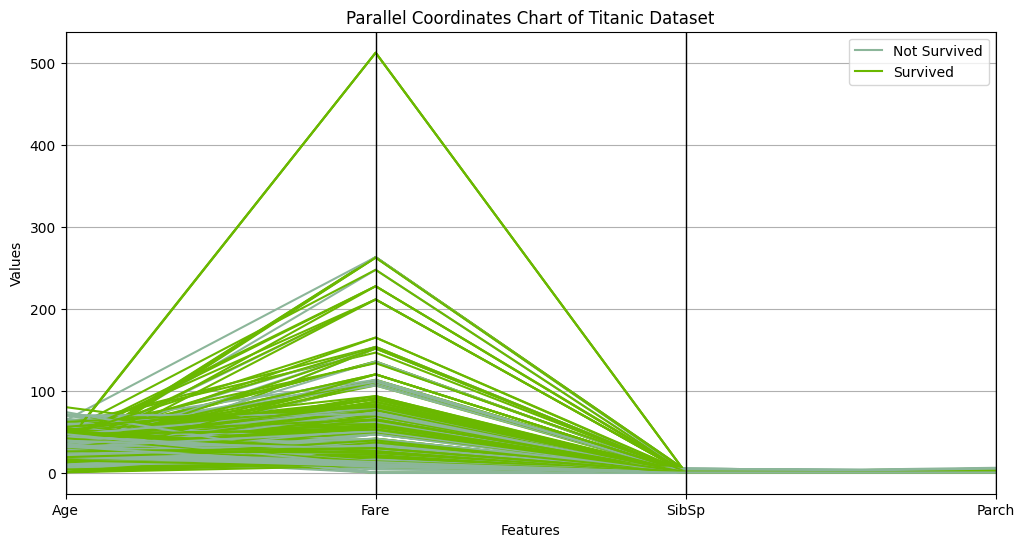

In [ ]:
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

data = df[["Survived", "Age", "Fare", "SibSp", "Parch"]].dropna()

data["Survival"] = data["Survived"].map({
    0: "Not Survived",
    1: "Survived"
})

data = data.drop("Survived", axis=1)

plt.figure(figsize=(12, 6))

parallel_coordinates(
    data,
    "Survival"
)

plt.title("Parallel Coordinates Chart of Titanic Dataset")
plt.xlabel("Features")
plt.ylabel("Values")

plt.show()

# Deviation Chart

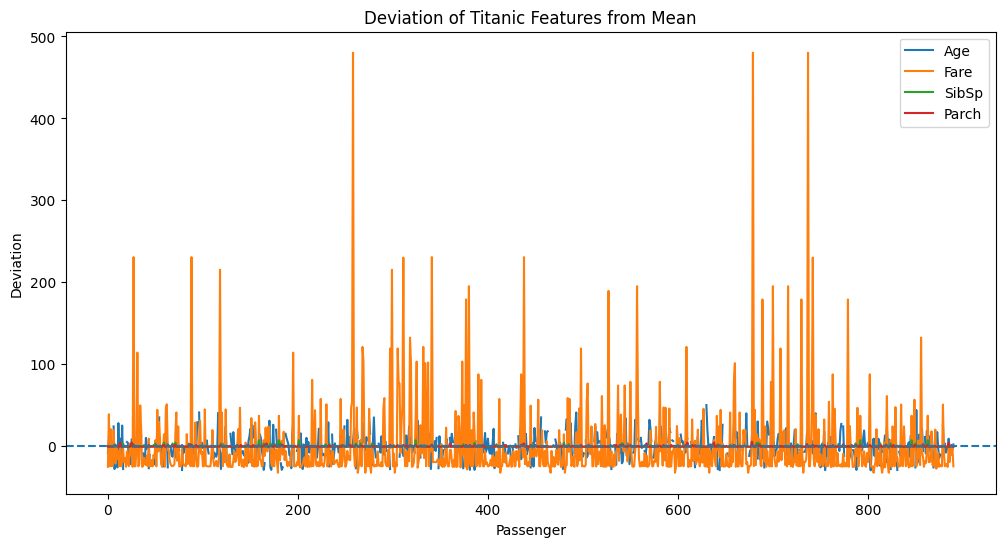

In [ ]:
import matplotlib.pyplot as plt

features = ["Age", "Fare", "SibSp", "Parch"]

deviation = df[features] - df[features].mean()

deviation.plot(figsize=(12, 6))

plt.axhline(0, linestyle="--")

plt.title("Deviation of Titanic Features from Mean")
plt.xlabel("Passenger")
plt.ylabel("Deviation")
plt.show()

# Andrews Curve

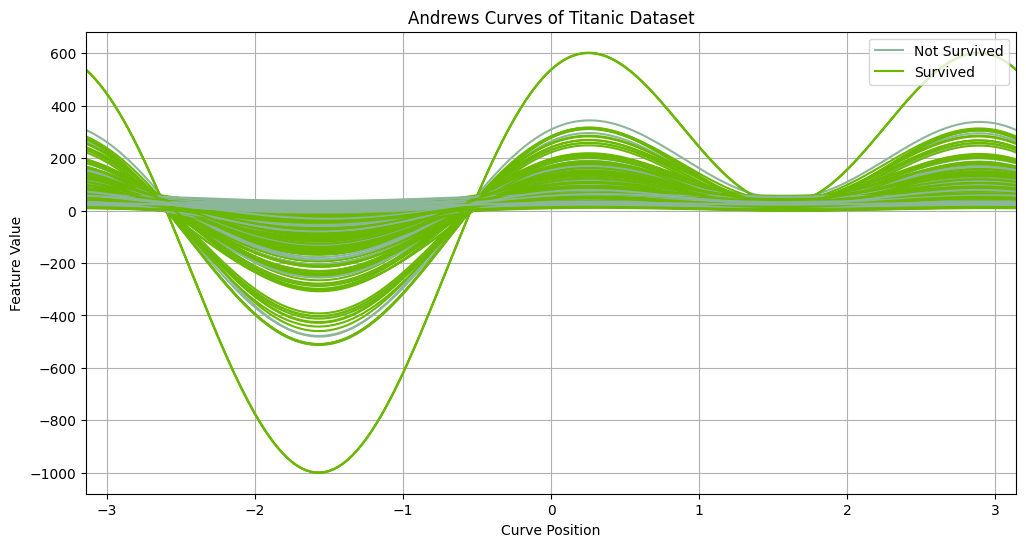

In [ ]:
import matplotlib.pyplot as plt
from pandas.plotting import andrews_curves

data = df[["Survived", "Age", "Fare", "SibSp", "Parch"]].dropna()

data["Survival"] = data["Survived"].map({
    0: "Not Survived",
    1: "Survived"
})

data = data.drop("Survived", axis=1)

plt.figure(figsize=(12, 6))

andrews_curves(
    data,
    "Survival"
)

plt.title("Andrews Curves of Titanic Dataset")
plt.xlabel("Curve Position")
plt.ylabel("Feature Value")

plt.show()

## **1.What percentage of passengers survived?**
Approximately 38.38% of passengers survived, indicating that less than 40% of the passengers survived.

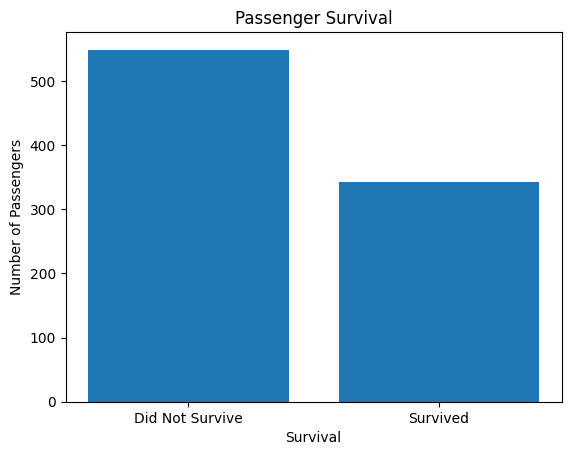

Survival Percentage: 38.38 %


In [ ]:
survival = df["Survived"].value_counts()

plt.bar(["Did Not Survive", "Survived"], survival)
plt.title("Passenger Survival")
plt.xlabel("Survival")
plt.ylabel("Number of Passengers")
plt.show()

percentage = df["Survived"].mean() * 100

print("Survival Percentage:", round(percentage, 2), "%")

### **2.Did gender influence survival chances?**
Women had significantly higher survival chances than men.

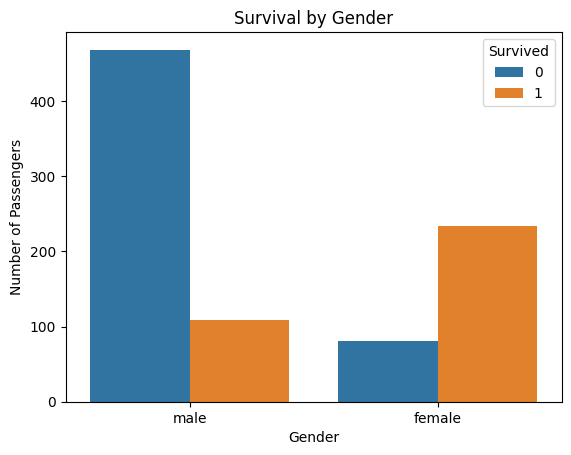

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="Sex",
    hue="Survived"
)

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

### **3.How did passenger class affect survival?**

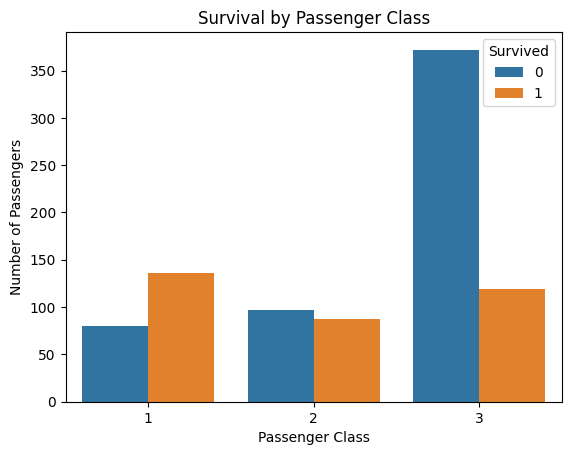

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

### **4.Was age a factor in survival?**
Age influenced survival chances, with children generally having better survival chances than adults.

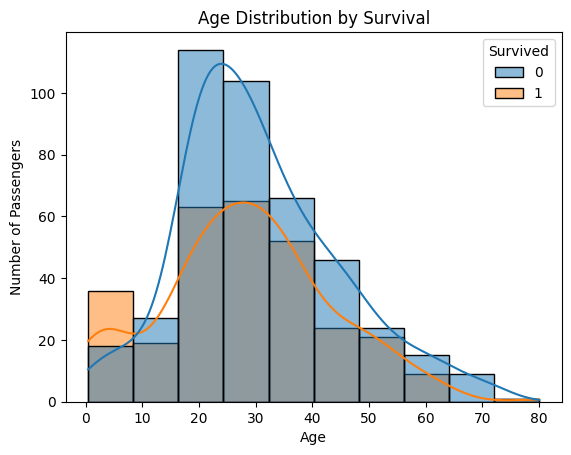

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(
    data=df,
    x="Age",
    hue="Survived",
    bins=10,
    kde=True
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

### **5.Which age group had the highest survival rate?**
Children had the highest survival rate, while elderly passengers generally had lower survival chances.

AgeGroup
Children    57.971014
Youth       41.052632
Adults      38.931298
Elderly     26.923077
Name: Survived, dtype: float64


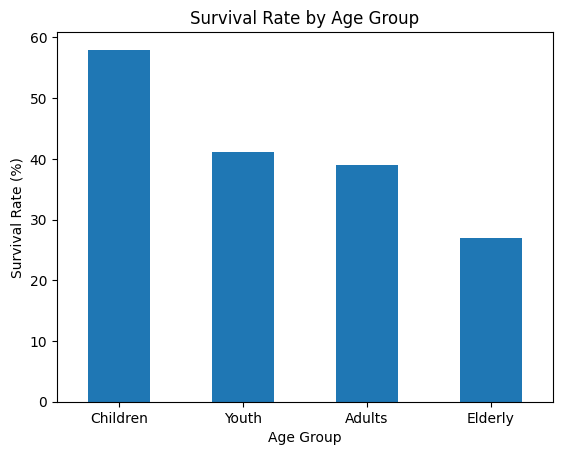

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 19, 59, 100],
    labels=["Children", "Youth", "Adults", "Elderly"]
)

survival_rate = df.groupby(
    "AgeGroup", observed=True
)["Survived"].mean() * 100

print(survival_rate)

survival_rate.plot(kind="bar")

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate (%)")
plt.xticks(rotation=0)
plt.show()

### **6.Did family size affect survival chances?**
Passengers with small family sizes (2–4 members) generally had better survival chances

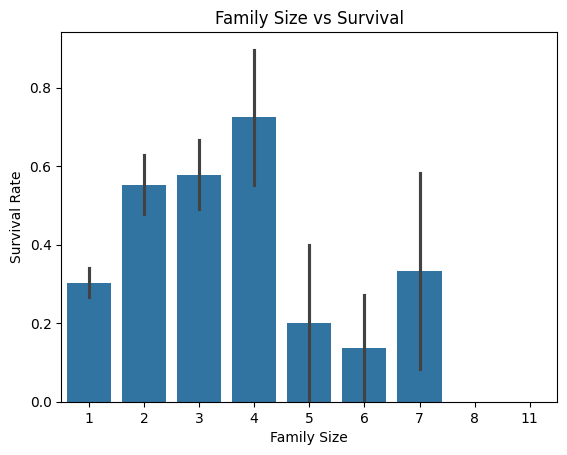

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create family size
df["family_size"] = df["SibSp"] + df["Parch"] + 1

# Compare family size and survival
sns.barplot(
    data=df,
    x="family_size",
    y="Survived"
)

plt.title("Family Size vs Survival")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.show()

### **7.Did the embarkation port influence survival?**
Passengers from Cherbourg had a higher survival rate

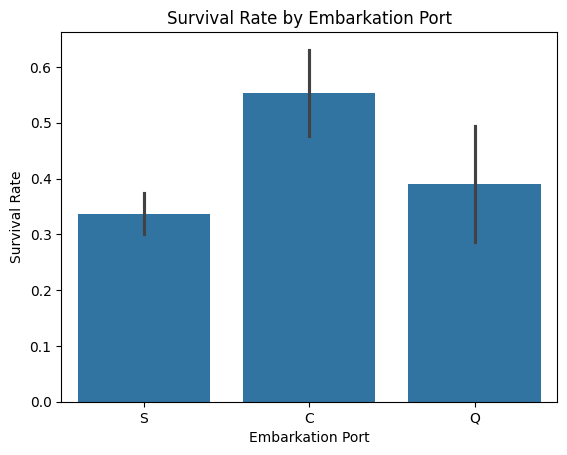

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    data=df,
    x="Embarked",
    y="Survived"
)

plt.title("Survival Rate by Embarkation Port")
plt.xlabel("Embarkation Port")
plt.ylabel("Survival Rate")
plt.show()

### **8.Did fare have any relationship with survival?**
Passengers who paid higher fares generally had better chances of survival.

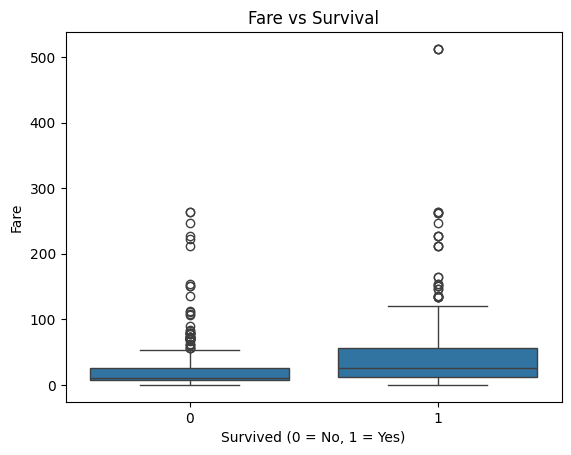

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    data=df,
    x="Survived",
    y="Fare"
)

plt.title("Fare vs Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Fare")
plt.show()

### **9.Which combination of factors best explains survival?**
Gender and passenger class have strong effects on survival

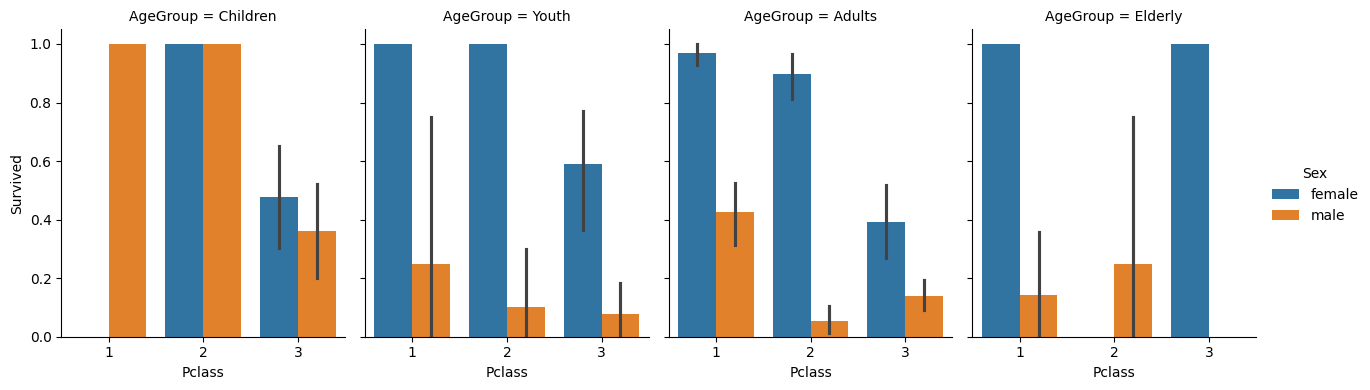

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create age groups
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[0, 12, 19, 59, 100],
    labels=["Children", "Youth", "Adults", "Elderly"]
)

# Compare survival by gender, class and age group
sns.catplot(
    data=df,
    x="Pclass",
    y="Survived",
    hue="Sex",
    col="AgeGroup",
    kind="bar",
    height=4,
    aspect=0.8
)

plt.show()

### **10.Were there passengers with missing data?**
The dataset contains missing values in Age (177), Cabin (687), and Embarked (2). AgeGroup also has 177 missing values because it is derived from Age

In [ ]:
missing = df.isnull().sum()

print(missing[missing > 0])

Age         177
Cabin       687
Embarked      2
AgeGroup    177
dtype: int64
